# Productivity of LA-5 Countries

## Still pending:
- Fix inconsistency in units.
- Reproduce productivity shocks.

## Libraries

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import ar model
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm

## Import data

In [200]:
data_1953_2010 = pd.read_excel('../_data/10sd_jan15_2014.xlsx', sheet_name='dataset')
data_1990_2018 = pd.read_excel('../_data/ETD_230918.xlsx', sheet_name='Data')

### Initial data: From 1953 to 2010

In [201]:
data_1953_2010.columns = data_1953_2010.columns.str.strip()

df_initial = data_1953_2010[data_1953_2010['Country'].isin(['BRA', 'CHL', 'COL', 'MEX', 'PER'])]
df_initial = df_initial[df_initial['Variable'].isin(['VA_Q05', 'EMP'])]
columns_needed_in = [
    'Utilities', 'Construction',
    'Trade, restaurants and hotels', 'Transport, storage and communication', 
    'Government services', 'Community, social and personal services'
]
df_initial = df_initial[['Country', 'Variable', 'Year'] + columns_needed_in]

In [202]:
data_1990_2018.columns = data_1990_2018.columns.str.strip()

df_final = data_1990_2018[data_1990_2018['cnt'].isin(['BRA', 'CHL', 'COL', 'MEX', 'PER'])]
df_final = df_final[df_final['var'].isin(['VA_Q15', 'EMP'])]
columns_needed_fin = [
    'Utilities', 'Construction', 'Trade services', 
    'Transport services', 'Government services', 'Other services'
]
df_final = df_final[['cnt', 'var', 'year'] + columns_needed_fin]

In [ ]:
# BUG FIX: The original code assigned value_added/employment back to the full
# df_initial frame using a boolean-filtered RHS, which propagates NaN to the
# rows belonging to the other variable. Split first, then compute on each slice.
df_initial_va = df_initial[df_initial['Variable'] == 'VA_Q05'].copy()
df_initial_emp = df_initial[df_initial['Variable'] == 'EMP'].copy()

# Coerce annotation strings to NaN before summing.
# min_count=1 ensures an all-NaN row (missing observation) stays NaN
# rather than being silently coerced to 0 by the default skipna=True sum.
df_initial_va['value_added'] = (
    df_initial_va[columns_needed_in].apply(pd.to_numeric, errors='coerce')
    .sum(axis=1, min_count=1) * 1_000_000
)
df_initial_emp['employment'] = (
    df_initial_emp[columns_needed_in].apply(pd.to_numeric, errors='coerce')
    .sum(axis=1, min_count=1) * 1_000
)

df_in = pd.merge(df_initial_va[['Country', 'Year', 'value_added']], df_initial_emp[['Country', 'Year', 'employment']], on=['Country', 'Year'])
df_in.head()

In [ ]:
# BUG FIX: Same chained-assignment issue as Cell 9. Split by variable first.
df_final_va = df_final[df_final['var'] == 'VA_Q15'].copy()
df_final_emp = df_final[df_final['var'] == 'EMP'].copy()

df_final_va['value_added'] = df_final_va[columns_needed_fin].sum(axis=1, min_count=1) * 1_000_000
df_final_emp['employment'] = df_final_emp[columns_needed_fin].sum(axis=1, min_count=1) * 1_000

df_fin = pd.merge(df_final_va[['cnt', 'year', 'value_added']], df_final_emp[['cnt', 'year', 'employment']], on=['cnt', 'year'])
df_fin.head()

In [205]:
df_in['prod'] = df_in.apply(
    lambda row: row['value_added'] / row['employment'] if row['employment'] > 0 else np.nan,
    axis=1
)
df_in.head()

,Country,Year,value_added,employment,prod
0,BRA,1950,62944659207.355331,4185847.521092,15037.494531
1,BRA,1951,67855993405.813393,4384086.011673,15477.797020
2,BRA,1952,75243346430.342804,4592432.823653,16384.201864
3,BRA,1953,75677594535.2836,4811434.275605,15728.697557
4,BRA,1954,84919688751.846832,5041667.514366,16843.571796


In [206]:
df_fin['prod'] = df_fin.apply(
    lambda row: row['value_added'] / row['employment'] if row['employment'] > 0 else np.nan,
    axis=1
)
df_fin.head()

,cnt,year,value_added,employment,prod
0,BRA,1990,1.501873e+12,34301185.0,43784.859673
1,BRA,1991,1.542318e+12,34249417.0,45031.942417
2,BRA,1992,1.562145e+12,34142831.0,45753.237942
3,BRA,1993,1.560449e+12,34937796.0,44663.639737
4,BRA,1994,1.631843e+12,35490568.0,45979.631361


In [207]:
# BUG FIX: groupby().apply(lambda x: x.pct_change().reset_index(drop=True)).reset_index(drop=True)
# resets positional indices 0,1,2,... but df_in retains its original integer index,
# so the assignment silently misaligns values across country groups.
# Use .transform() which preserves the original index alignment.
df_in['prod_growth'] = df_in.groupby('Country')['prod'].transform(lambda x: x.pct_change())
df_in.head()

,Country,Year,value_added,employment,prod,prod_growth
0,BRA,1950,62944659207.355331,4185847.521092,15037.494531,NaN
1,BRA,1951,67855993405.813393,4384086.011673,15477.797020,0.029280
2,BRA,1952,75243346430.342804,4592432.823653,16384.201864,0.058562
3,BRA,1953,75677594535.2836,4811434.275605,15728.697557,-0.040008
4,BRA,1954,84919688751.846832,5041667.514366,16843.571796,0.070882


In [208]:
# BUG FIX: Same index-misalignment issue as Cell 13. Use .transform().
df_fin['prod_growth'] = df_fin.groupby('cnt')['prod'].transform(lambda x: x.pct_change())
df_fin.head()

,cnt,year,value_added,employment,prod,prod_growth
0,BRA,1990,1.501873e+12,34301185.0,43784.859673,NaN
1,BRA,1991,1.542318e+12,34249417.0,45031.942417,0.028482
2,BRA,1992,1.562145e+12,34142831.0,45753.237942,0.016017
3,BRA,1993,1.560449e+12,34937796.0,44663.639737,-0.023815
4,BRA,1994,1.631843e+12,35490568.0,45979.631361,0.029464


In [209]:
# Country codes used throughout (defined here so all downstream cells can use them)
countries = ['BRA', 'CHL', 'COL', 'MEX', 'PER']

# ── xkcd vivid color palette ─────────────────────────────────────────
COLORS = {
    'BRA': 'xkcd:azure',
    'CHL': 'xkcd:grass green',
    'COL': 'xkcd:tangerine',
    'MEX': 'xkcd:magenta',
    'PER': 'xkcd:cerulean',
}
COUNTRY_NAMES = {
    'BRA': 'Brazil', 'CHL': 'Chile', 'COL': 'Colombia',
    'MEX': 'Mexico', 'PER': 'Peru',
}

def style_ax(ax, xlabel='Year', ylabel='', title=''):
    """Apply Healy-style formatting to an Axes object."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)
    ax.tick_params(axis='both', which='both', length=3, width=0.6, labelsize=9)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10, labelpad=4)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10, labelpad=4)
    if title:
        ax.set_title(title, fontsize=11, fontweight='normal', loc='left', pad=4)


plt.rcParams.update({
    'text.usetex'         : True,
    'font.family'         : 'serif',
    'font.serif'          : ['Computer Modern'],
    'text.latex.preamble' : r'\usepackage{amsmath}',
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'axes.grid'           : False,
    'axes.linewidth'      : 0.6,
    'lines.linewidth'     : 1.8,
    'figure.dpi'          : 300,
})


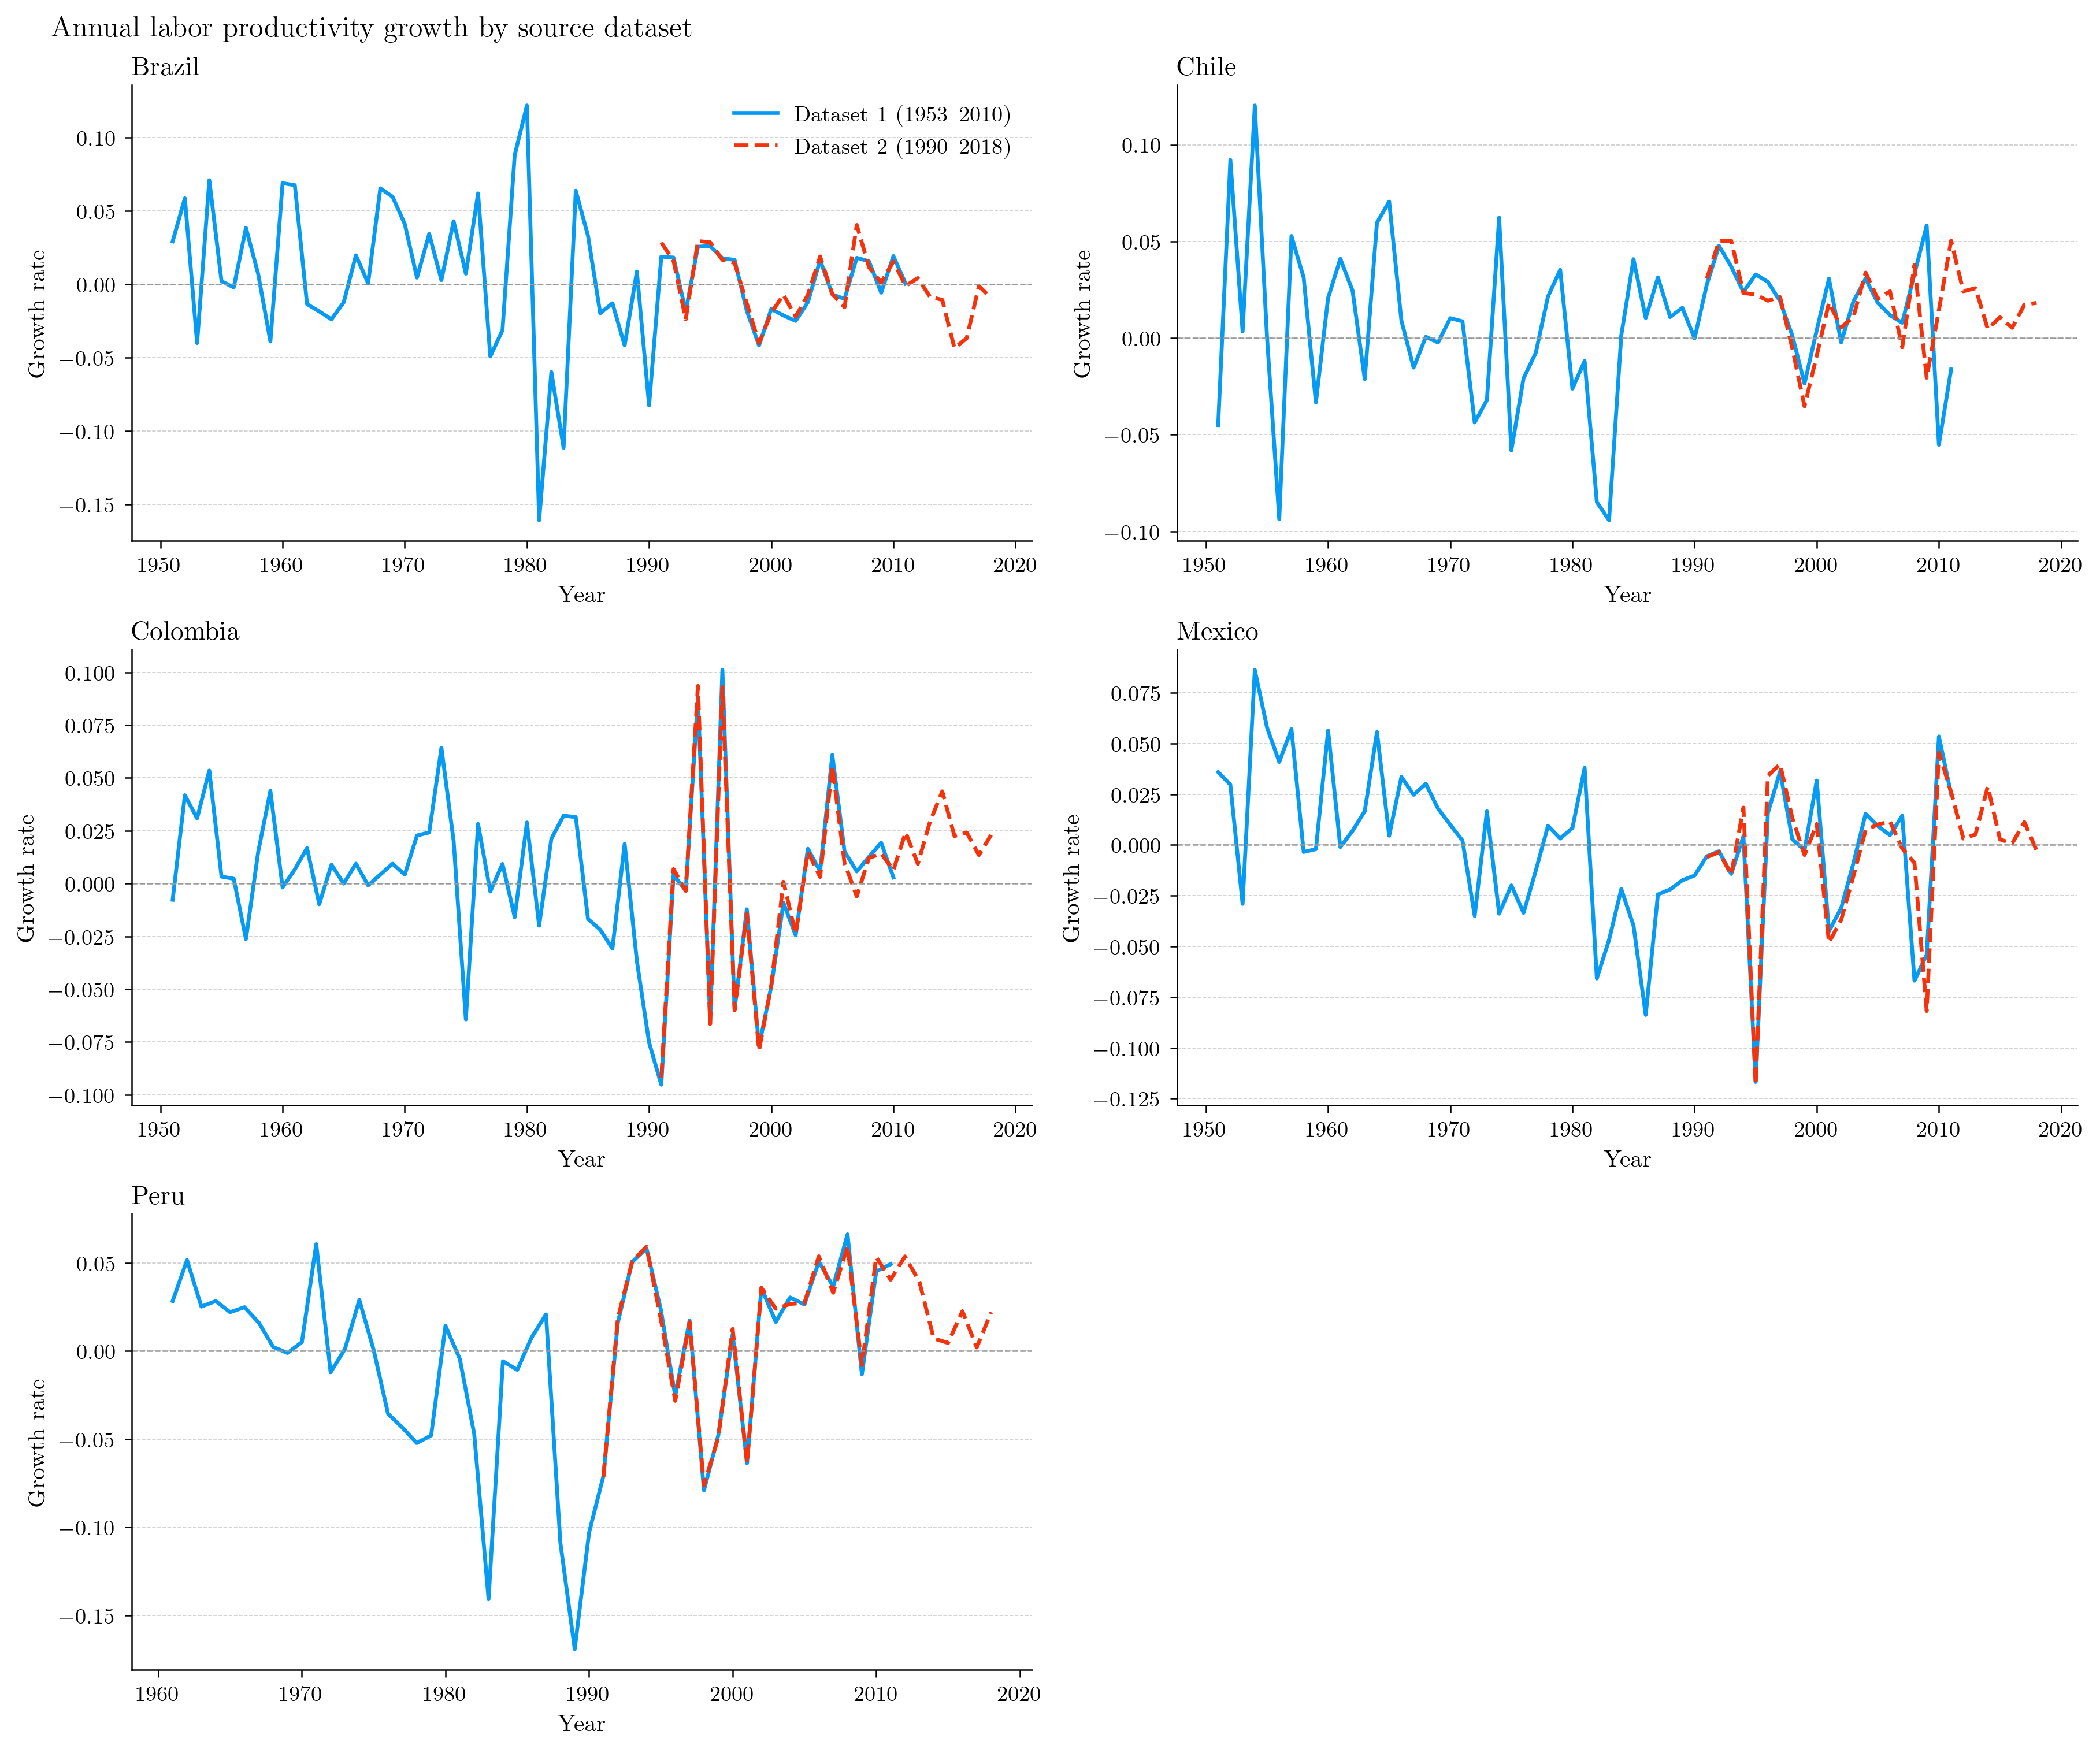

In [210]:
# Compare annual productivity growth across the two source datasets.
# Two colors distinguish sources; country panels make comparison direct.
C1, C2 = 'xkcd:azure', 'xkcd:vermillion'   # source 1 (solid) / source 2 (dashed)

fig, axs = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.ravel()

for i, country in enumerate(countries):
    df_c1 = df_in[df_in['Country'] == country]
    df_c2 = df_fin[df_fin['cnt'] == country]

    axs[i].plot(df_c1['Year'], df_c1['prod_growth'],
                color=C1, linewidth=1.6, label='Dataset 1 (1953--2010)')
    axs[i].plot(df_c2['year'], df_c2['prod_growth'],
                color=C2, linewidth=1.6, linestyle='--', label='Dataset 2 (1990--2018)')
    axs[i].axhline(0, color='#999999', linewidth=0.6, linestyle='--')

    style_ax(axs[i], xlabel='Year', ylabel='Growth rate',
             title=COUNTRY_NAMES[country])

    # Show legend only on first panel to avoid repetition
    if i == 0:
        axs[i].legend(fontsize=9, frameon=False)

if len(countries) < len(axs):
    fig.delaxes(axs[-1])

fig.suptitle('Annual labor productivity growth by source dataset',
             fontsize=12, x=0.02, ha='left')
fig.savefig('../_results/_figures/prod_growth.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [211]:
print(countries)
# Change name of "cnt" column to "Country" in df_fin
df_fin = df_fin.rename(columns={'cnt': 'Country'})
# Rename year to Year in df_fin
df_fin = df_fin.rename(columns={'year': 'Year'})

# merge both datasets, keeping all rows
df = pd.merge(df_in, df_fin, on=['Country', 'Year'], how='outer')
# Sort by Country and Year; reset index for clean integer-based .loc access
df = df.sort_values(by=['Country', 'Year']).reset_index(drop=True)

# Chain prod_x (initial dataset, 2005 USD) forward using prod_growth_y (ETD dataset)
# for the years not covered by the initial dataset.
# NOTE: prod_x uses 2005 constant USD and prod_y uses 2015 constant USD, so this
# chaining preserves growth rates but the level remains in 2005 USD throughout.
# BUG FIX: The loop originally started at 2010, overwriting the real 2010 value
# from the initial dataset with a chained estimate. Start at 2011 instead.

for year in range(2011, 2019):
    for country in countries:
        # multiply prod_x by (1 + prod_growth_y) to extend the series
        df.loc[(df['Country'] == country) & (df['Year'] == year), 'prod_x'] = (
            df.loc[(df['Country'] == country) & (df['Year'] == year - 1), 'prod_x'].values[0]
            * (1 + df.loc[(df['Country'] == country) & (df['Year'] == year), 'prod_growth_y'].values[0])
        )

df.head()


['BRA', 'CHL', 'COL', 'MEX', 'PER']


,Country,Year,value_added_x,employment_x,prod_x,prod_growth_x,value_added_y,employment_y,prod_y,prod_growth_y
0,BRA,1950,62944659207.355331,4185847.521092,15037.494531,NaN,NaN,NaN,NaN,NaN
1,BRA,1951,67855993405.813393,4384086.011673,15477.797020,0.029280,NaN,NaN,NaN,NaN
2,BRA,1952,75243346430.342804,4592432.823653,16384.201864,0.058562,NaN,NaN,NaN,NaN
3,BRA,1953,75677594535.2836,4811434.275605,15728.697557,-0.040008,NaN,NaN,NaN,NaN
4,BRA,1954,84919688751.846832,5041667.514366,16843.571796,0.070882,NaN,NaN,NaN,NaN


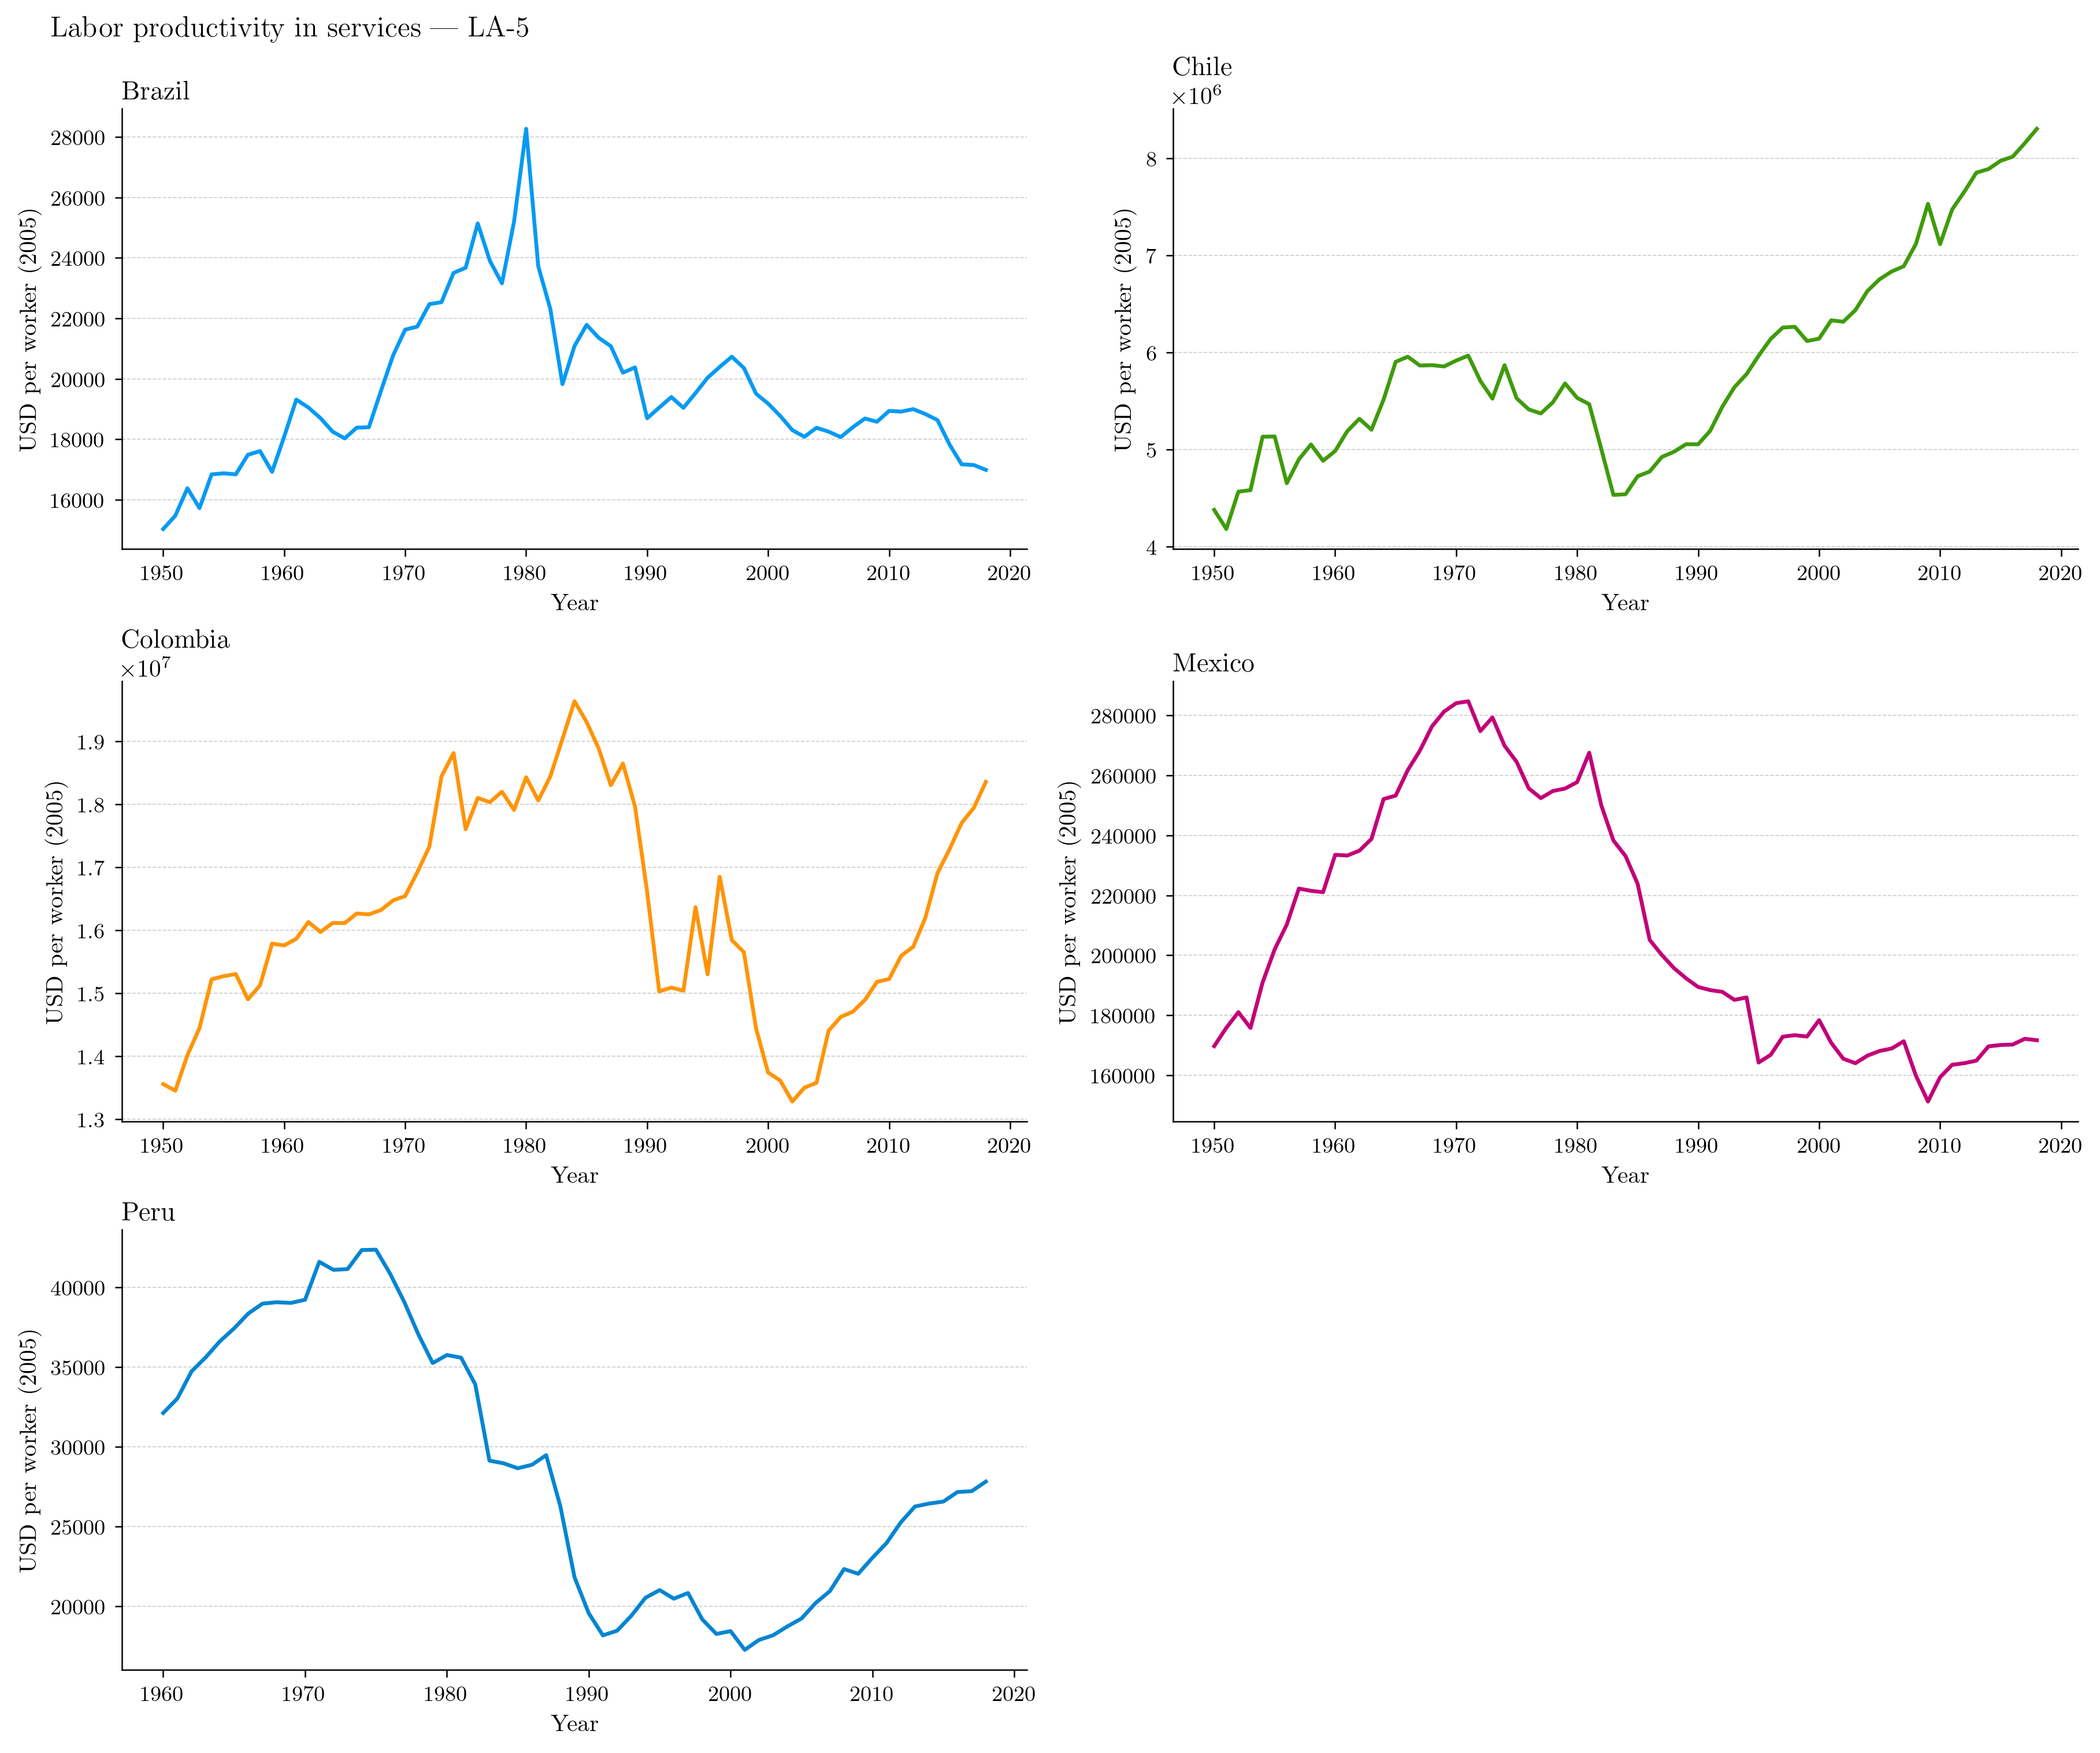

In [212]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.ravel()

for i, country in enumerate(countries):
    df_country = df[df['Country'] == country]
    axs[i].plot(df_country['Year'], df_country['prod_x'],
                color=COLORS[country], linewidth=1.6)
    style_ax(axs[i], xlabel='Year',
             ylabel='USD per worker (2005)',
             title=COUNTRY_NAMES[country])

if len(countries) < len(axs):
    fig.delaxes(axs[-1])

fig.suptitle('Labor productivity in services --- LA-5',
             fontsize=12, x=0.02, ha='left')
fig.savefig('../_results/_figures/productivity.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [213]:
# EXPLORATORY: AR(1) on log-levels of productivity (non-stationary series).
# The AR root modulus is >= 1 for several countries (unit root / near-unit-root),
# confirming these log-level series are I(1). Do NOT interpret the AR coefficient
# here as a persistence parameter for a stationary process — use the detrended
# series in the cells below for structural estimation.
# A proper DatetimeIndex is set to suppress the statsmodels index warning.

for country in countries:
    print(country)
    df_country = df[df['Country'] == country].dropna(subset=['prod_x']).copy()
    # Set a proper annual DatetimeIndex so AutoReg can generate forecasts
    df_country.index = pd.DatetimeIndex(pd.to_datetime(df_country['Year'], format='%Y'), freq='YS')
    model = AutoReg(np.log(df_country['prod_x']), lags=1)
    model_fit = model.fit()
    print(model_fit.summary())


BRA
                            AutoReg Model Results                             
Dep. Variable:                 prod_x   No. Observations:                   69
Model:                     AutoReg(1)   Log Likelihood                 116.602
Method:               Conditional MLE   S.D. of innovations              0.044
Date:                Tue, 07 Apr 2026   AIC                           -227.204
Time:                        22:53:35   BIC                           -220.546
Sample:                    01-01-1951   HQIC                          -224.566
                         - 01-01-2018                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9313      0.432      2.154      0.031       0.084       1.779
prod_x.L1      0.9059      0.044     20.696      0.000       0.820       0.992
                                    Roots       

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarnin

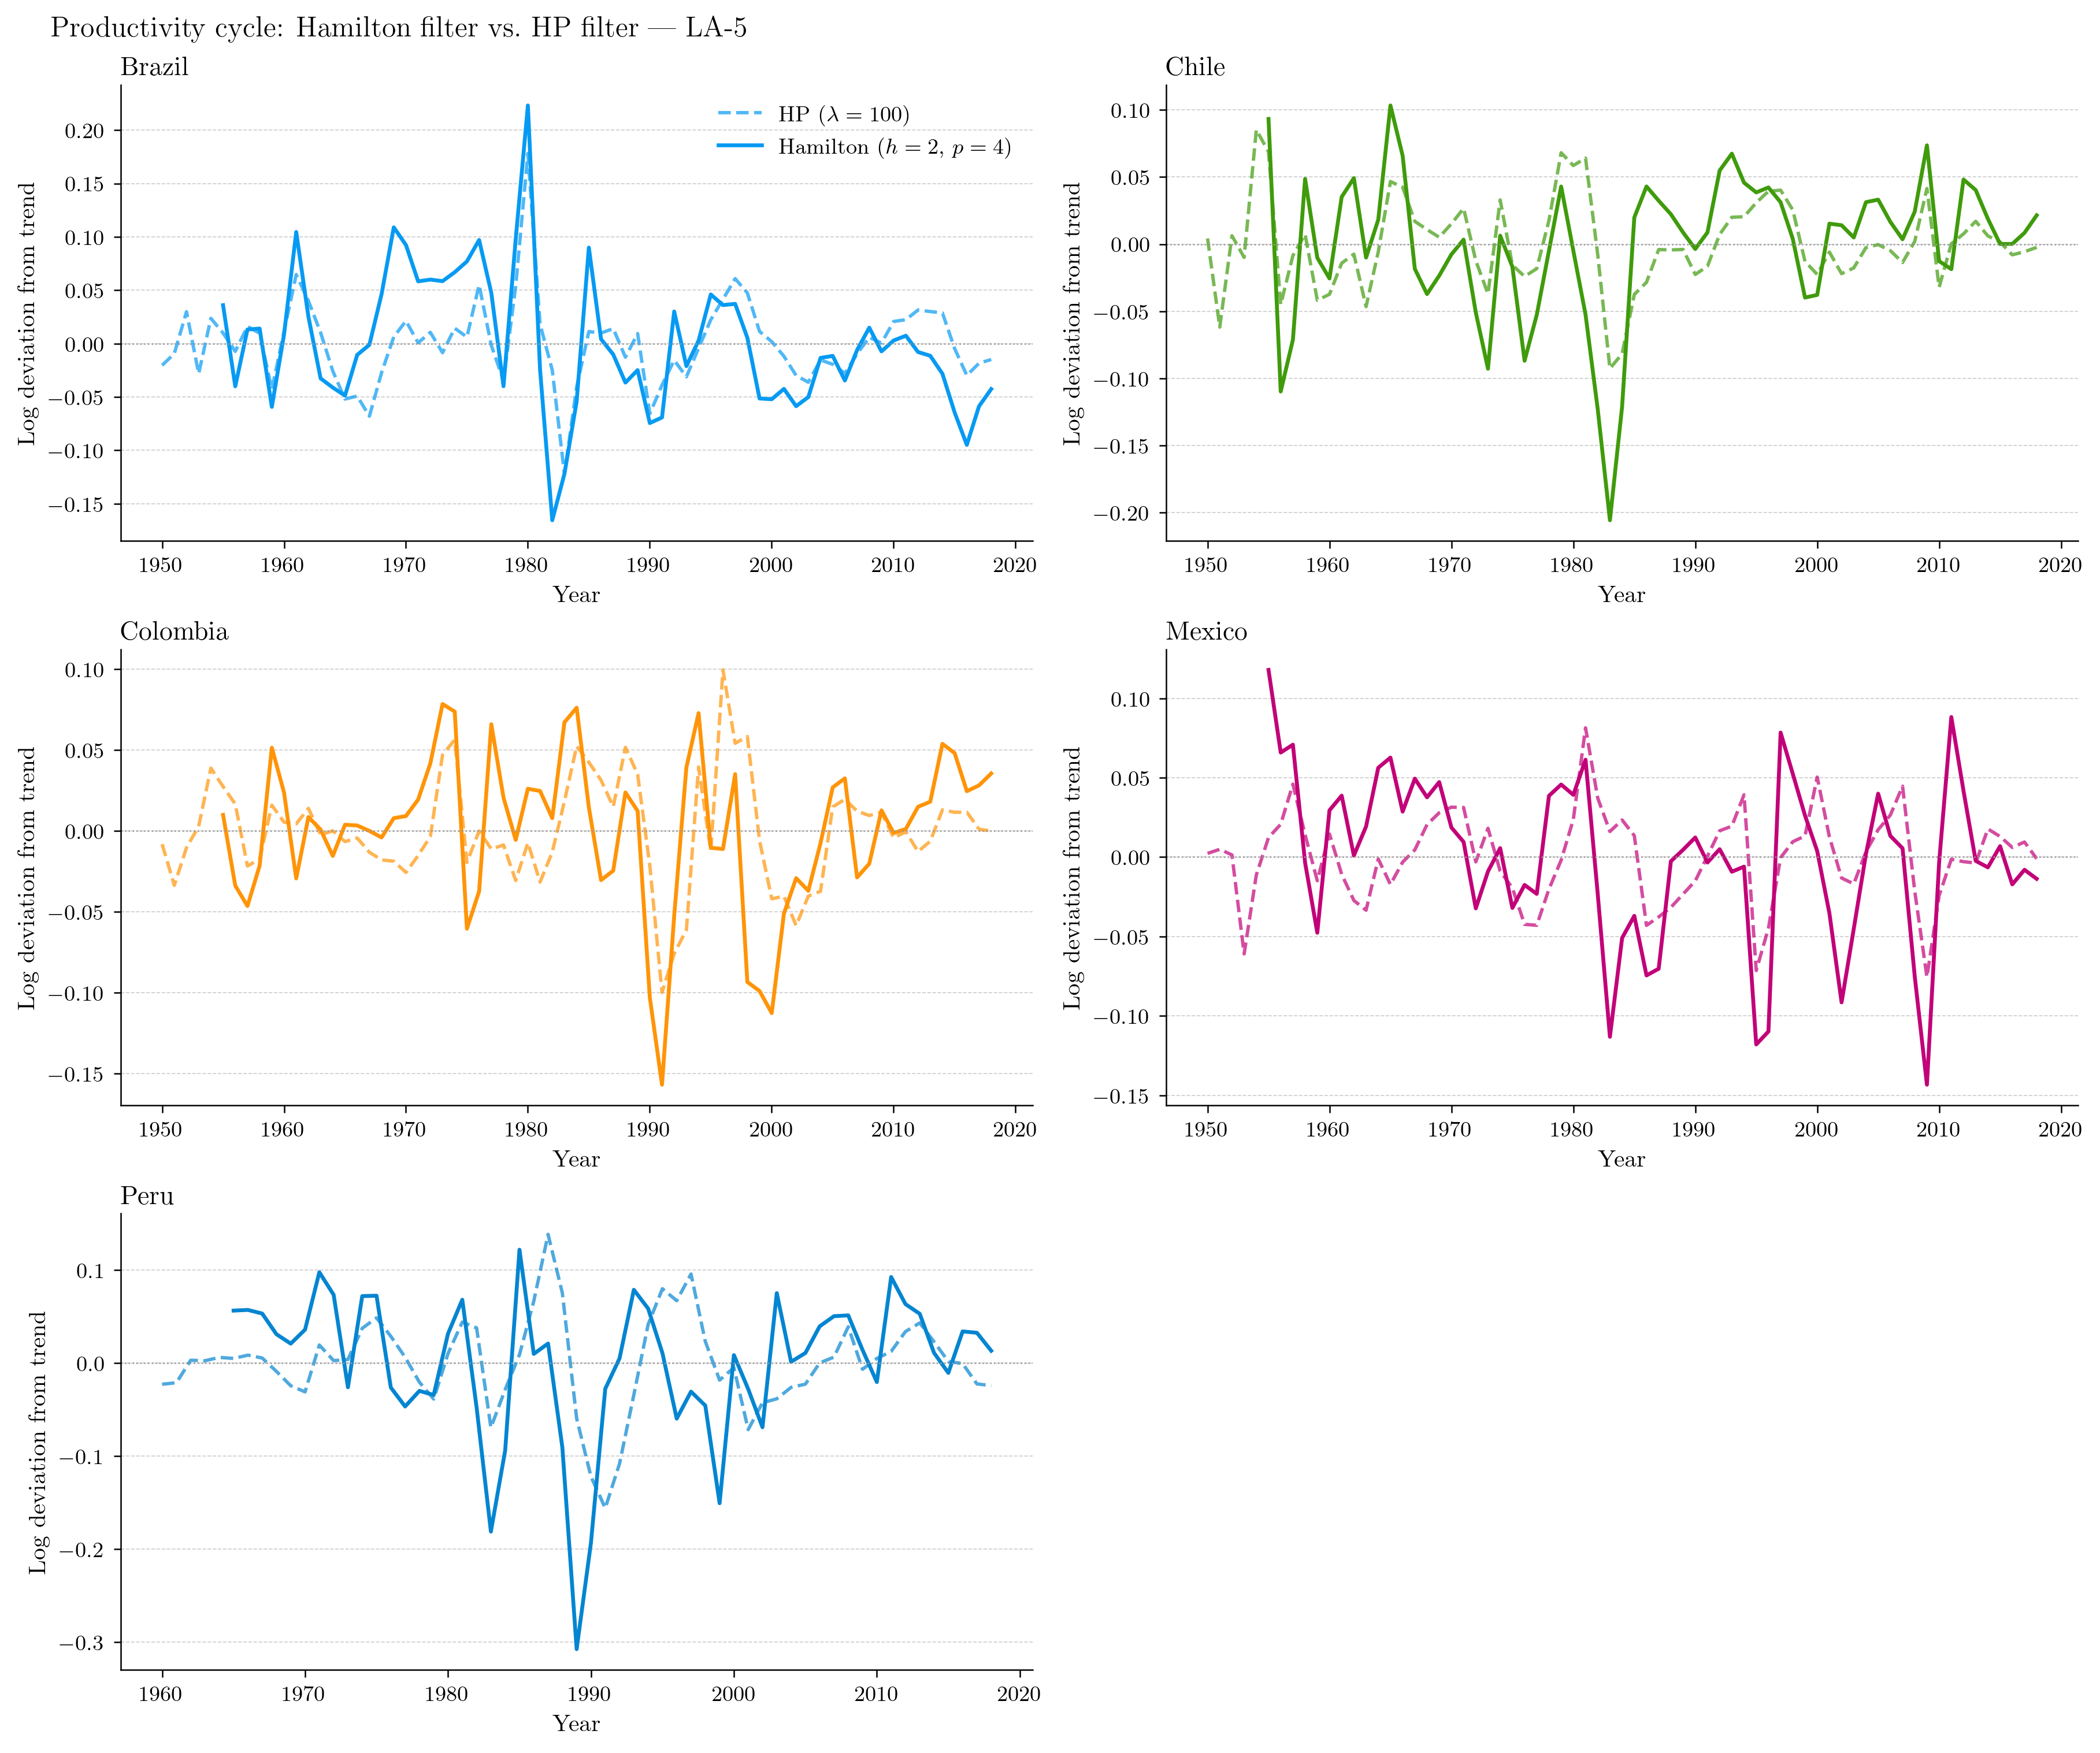

In [214]:
def hamilton_filter(log_y, h=2, p=4):
    """
    Hamilton (2018) regression filter.

    Regresses log_y[t] on log_y[t-h], log_y[t-h-1], ..., log_y[t-h-p+1]
    via OLS. The residual is the cyclical component.

    Advantages over HP filter:
      - No endpoint bias: zero observations lost at the END of the sample.
      - No spurious cycles induced by the two-sided smoother.
      - Standard OLS inference applies.
    Cost: loses the first h+p-1 observations at the START (t0 = h+p-1).

    Parameters
    ----------
    log_y : array-like  Log-productivity series (length T).
    h     : int         Forecast horizon. Hamilton recommends h=2 for annual data.
    p     : int         Number of lags.   Hamilton recommends p=4.

    Returns
    -------
    cycle : np.ndarray, length T
        Cyclical component. NaN for the first h+p-1 = 5 observations.
    fit   : OLS RegressionResultsWrapper
        Full OLS results for diagnostics.
    """
    y  = np.asarray(log_y, dtype=float)
    T  = len(y)
    t0 = h + p - 1                   # index of first valid obs (0-based)
    Y  = y[t0:]
    X  = np.column_stack([y[(t0 - h - j):(T - h - j)] for j in range(p)])
    X  = sm.add_constant(X)
    fit = sm.OLS(Y, X).fit()
    cycle = np.full(T, np.nan)
    cycle[t0:] = fit.resid
    return cycle, fit


# Drop rows with missing productivity before filtering
df = df.dropna(subset=['prod_x'])

# Apply the Hamilton filter (h=2, p=4 -- Hamilton's recommendations for annual
# data) to log-productivity for each country separately.
# The cyclical component is stored as 'prod_x_detrended'.
# NOTE: the first h+p-1 = 5 years of each country's series will be NaN
#       (e.g. 1950-1954 for BRA/CHL/COL/MEX, 1960-1964 for PER).
H, P = 2, 4
for country in countries:
    df_country = df[df['Country'] == country].copy()
    cycle, _ = hamilton_filter(np.log(df_country['prod_x']), h=H, p=P)
    df.loc[df['Country'] == country, 'prod_x_detrended'] = cycle

# Apply HP filter (lambda=100) to the same log-productivity series for comparison.
# prod_x_detrended_hp is the HP cyclical component; endpoint bias affects the
# first and last ~5 years of each country's series.
from statsmodels.tsa.filters.hp_filter import hpfilter as hp_filter
HP_LAMBDA = 100
for country in countries:
    df_country = df[df['Country'] == country].copy()
    hp_cycle, _ = hp_filter(np.log(df_country['prod_x']), lamb=HP_LAMBDA)
    df.loc[df['Country'] == country, 'prod_x_detrended_hp'] = hp_cycle.values

# Overlay plot: Hamilton cycle vs HP cycle for each country
fig, axs = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.ravel()

for i, country in enumerate(countries):
    df_country = df[df['Country'] == country]
    axs[i].plot(df_country['Year'], df_country['prod_x_detrended_hp'],
                color=COLORS[country], linewidth=1.4, linestyle='--',
                alpha=0.7, label=f'HP ($\\lambda={HP_LAMBDA}$)')
    axs[i].plot(df_country['Year'], df_country['prod_x_detrended'],
                color=COLORS[country], linewidth=1.6,
                label=f'Hamilton ($h={H}$, $p={P}$)')
    axs[i].axhline(0, color='#999999', linewidth=0.6, linestyle=':')
    style_ax(axs[i], xlabel='Year',
             ylabel='Log deviation from trend',
             title=COUNTRY_NAMES[country])
    if i == 0:
        axs[i].legend(fontsize=9, frameon=False)

if len(countries) < len(axs):
    fig.delaxes(axs[-1])

fig.suptitle('Productivity cycle: Hamilton filter vs.\\ HP filter --- LA-5',
             fontsize=12, x=0.02, ha='left')
fig.savefig('../_results/_figures/productivity_detrended.pdf', format='pdf', bbox_inches='tight')
plt.show()


Hamilton filter (h=2, p=4):
  Country  Sample           N       rho  se(rho)   sigma_eps    var_eps
  ---------------------------------------------------------------------
  BRA      1955-2018       63    0.5124   0.1083    0.053583   0.002871
  CHL      1955-2018       63    0.4830   0.1070    0.045849   0.002102
  COL      1955-2018       63    0.5103   0.1090    0.040590   0.001648
  MEX      1955-2018       63    0.4772   0.1046    0.042867   0.001838
  PER      1965-2018       53    0.4688   0.1206    0.068708   0.004721
  ---------------------------------------------------------------------
  POOLED   1955-2018      305    0.4880   0.0652    0.050687   0.002569

HP filter (lambda=100):
  Country  Sample           N       rho  se(rho)   sigma_eps    var_eps
  ---------------------------------------------------------------------
  BRA      1950-2018       68    0.4329   0.1092    0.035278   0.001245
  CHL      1950-2018       68    0.4330   0.1093    0.029799   0.000888
  COL      

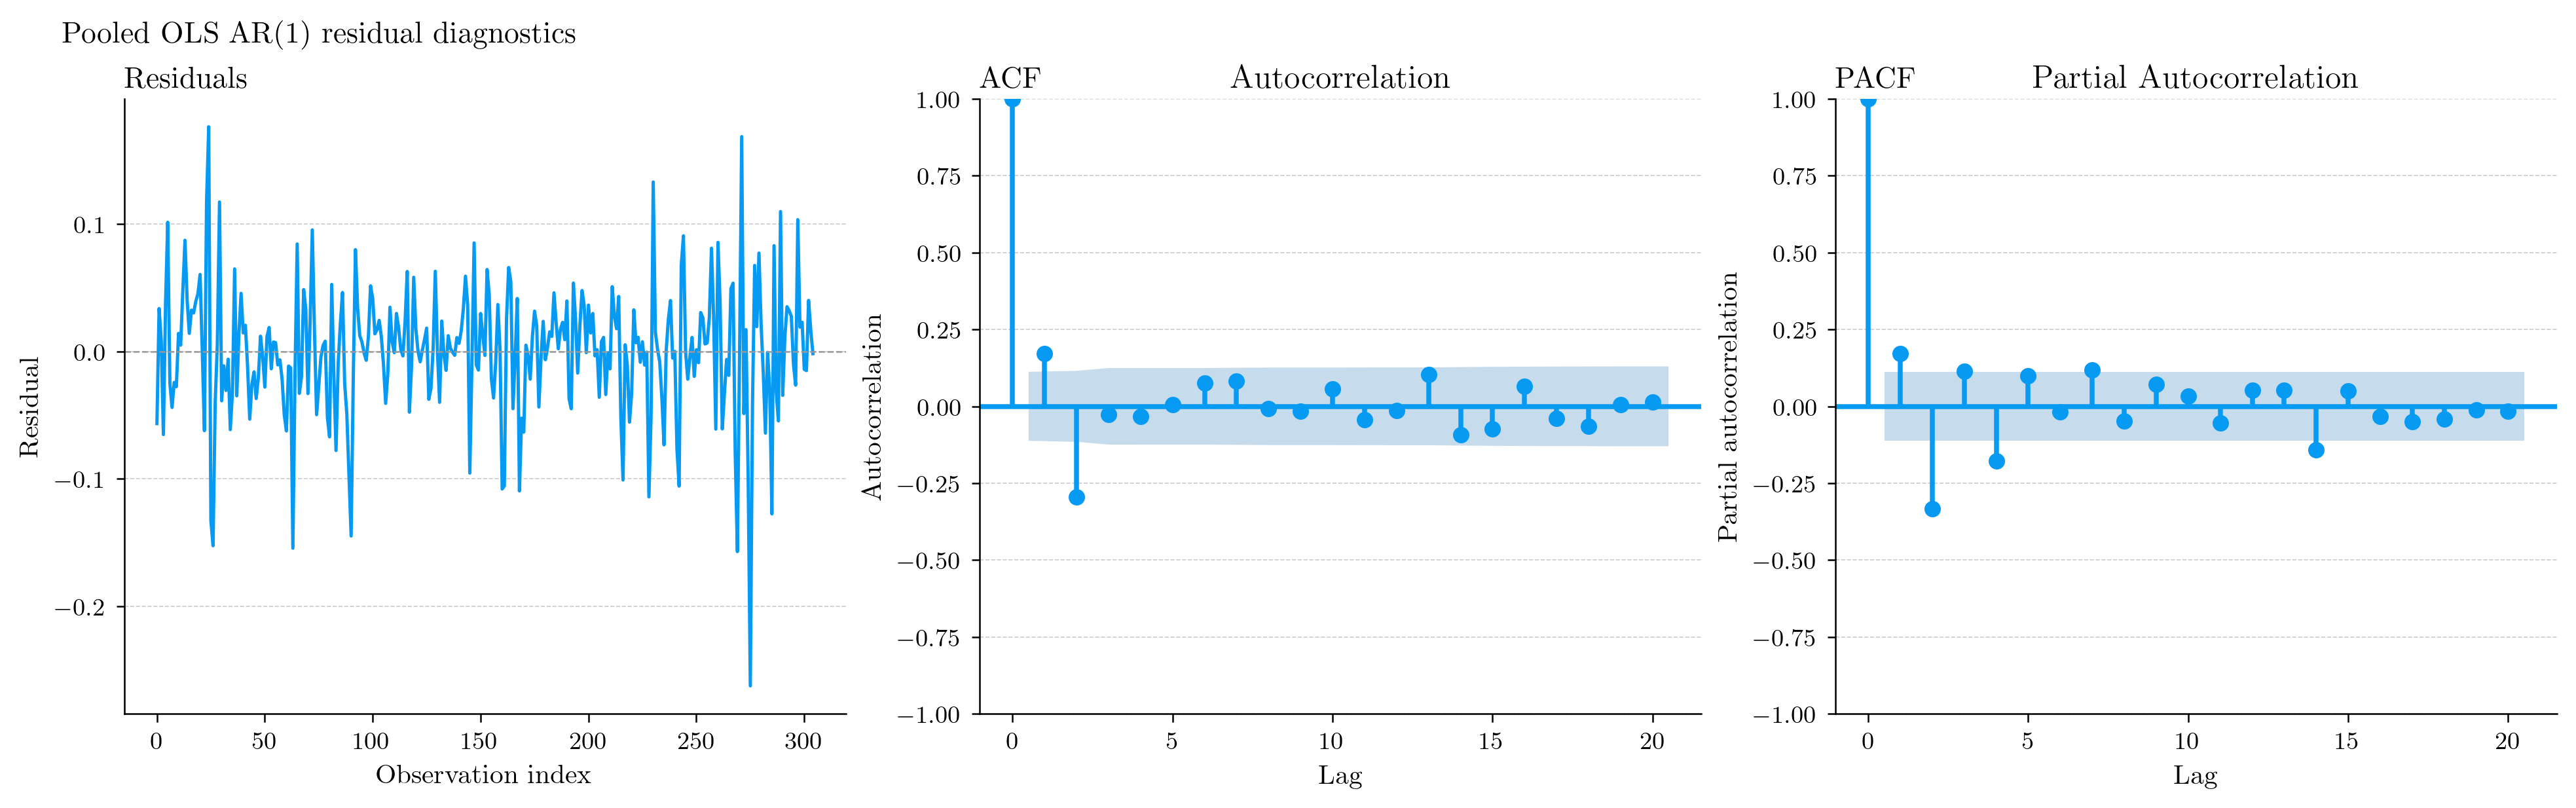

In [215]:
# AR(1) on both the Hamilton-filtered and HP-filtered cyclical components.
#
# Estimation sample after Hamilton filter (h=2, p=4):
#   - BRA, CHL, COL, MEX : cycle 1955-2018 = 64 obs, 63 AR(1) pairs
#                           (first 5 years 1950-1954 are NaN -- Hamilton filter burn-in)
#   - PER                 : cycle 1965-2018 = 54 obs, 53 AR(1) pairs
#                           (first 5 years 1960-1964 are NaN)
#
# NOTE: Unlike the HP filter, the Hamilton filter has no endpoint bias -- the
# last observation (2018) is estimated with the same precision as any interior
# observation. prod_x values for 2011-2018 remain gap-filled via chained growth
# rates, but they no longer receive additional distortion from endpoint smoothing.

# ── Column widths ────────────────────────────────────────────────────────────
W = {'country': 8, 'sample': 13, 'n': 4, 'rho': 8, 'se_rho': 8,
     'sigma': 10, 'var': 10}
SEP = '  '

def fmt_header():
    h  = f'  {"Country":<{W["country"]}} {"Sample":<{W["sample"]}} {"N":>{W["n"]}}'
    h += f'{SEP}{"rho":>{W["rho"]}} {"se(rho)":>{W["se_rho"]}}'
    h += f'{SEP}{"sigma_eps":>{W["sigma"]}} {"var_eps":>{W["var"]}}'
    return h

def fmt_row(country, sample, n, rho, se_rho, sigma, var):
    r  = f'  {country:<{W["country"]}} {sample:<{W["sample"]}} {n:>{W["n"]}}'
    r += f'{SEP}{rho:>{W["rho"]}.4f} {se_rho:>{W["se_rho"]}.4f}'
    r += f'{SEP}{sigma:>{W["sigma"]}.6f} {var:>{W["var"]}.6f}'
    return r

# FIX: derive divider width directly from the header to guarantee alignment
header  = fmt_header()
divider = '  ' + '-' * (len(header) - 2)

print('Hamilton filter (h=2, p=4):')
print(header)
print(divider)

ar_results_hamilton = {}
pooled_pairs = []
model_fits   = {}  # store fits to avoid refitting later

for country in countries:
    df_country = df[df['Country'] == country].dropna(subset=['prod_x_detrended']).copy()
    yr_min = int(df_country['Year'].min())
    yr_max = int(df_country['Year'].max())
    df_country.index = pd.DatetimeIndex(
        pd.to_datetime(df_country['Year'], format='%Y'), freq='YS'
    )
    model_fit = AutoReg(df_country['prod_x_detrended'], lags=1).fit()
    model_fits[country] = model_fit

    # FIX: use model_fit.nobs (= T - lags = effective regression obs) not len(df_country)
    n_obs = model_fit.nobs

    # FIX: use named parameter lookup instead of positional iloc[1]
    lag_param = [p for p in model_fit.params.index if p != 'const'][0]
    rho       = model_fit.params[lag_param]
    se_rho    = model_fit.bse[lag_param]
    sigma_eps = np.sqrt(model_fit.sigma2)
    var_eps   = model_fit.sigma2

    ar_results_hamilton[country] = dict(rho=rho, se_rho=se_rho,
                                        sigma_eps=sigma_eps, var_eps=var_eps,
                                        yr_min=yr_min, yr_max=yr_max, n_obs=n_obs)

    print(fmt_row(country, f'{yr_min}-{yr_max}', n_obs,
                  rho, se_rho, sigma_eps, var_eps))

    y = df_country['prod_x_detrended'].values
    pooled_pairs.append(pd.DataFrame({'y_t': y[1:], 'y_lag': y[:-1]}))

# ── Valid pooled OLS (HC1-robust SEs) ────────────────────────────────────────
# Lags are constructed within each country before stacking so no cross-country
# lag is ever formed. HC1-robust SEs account for heteroskedasticity across
# countries (innovation variances likely differ). sigma_eps uses RSS/N (MLE
# convention) to stay comparable with the per-country AutoReg estimates.
df_pairs       = pd.concat(pooled_pairs, ignore_index=True)
X_pool         = sm.add_constant(df_pairs['y_lag'])
# FIX: use HC1-robust covariance for the pooled OLS to account for
# cross-country heteroskedasticity in the stacked residuals
pooled_ols     = sm.OLS(df_pairs['y_t'], X_pool).fit(cov_type='HC1')
n_pairs        = len(df_pairs)
rho_pool       = pooled_ols.params['y_lag']
se_rho_pool    = pooled_ols.bse['y_lag']
var_eps_pool   = np.sum(pooled_ols.resid ** 2) / n_pairs
sigma_eps_pool = np.sqrt(var_eps_pool)
yr_min_pool    = min(v['yr_min'] for v in ar_results_hamilton.values())
yr_max_pool    = max(v['yr_max'] for v in ar_results_hamilton.values())

ar_results_hamilton['POOLED'] = dict(rho=rho_pool, se_rho=se_rho_pool,
                                     sigma_eps=sigma_eps_pool, var_eps=var_eps_pool,
                                     yr_min=yr_min_pool, yr_max=yr_max_pool, n_obs=n_pairs)

print(divider)
print(fmt_row('POOLED', f'{yr_min_pool}-{yr_max_pool}', n_pairs,
              rho_pool, se_rho_pool, sigma_eps_pool, var_eps_pool))
print()

# ── HP filter AR(1) ──────────────────────────────────────────────────────────
print('HP filter (lambda=100):')
print(header)
print(divider)

ar_results_hp   = {}
pooled_pairs_hp = []
model_fits_hp   = {}

for country in countries:
    df_country = df[df['Country'] == country].dropna(subset=['prod_x_detrended_hp']).copy()
    yr_min = int(df_country['Year'].min())
    yr_max = int(df_country['Year'].max())
    df_country.index = pd.DatetimeIndex(
        pd.to_datetime(df_country['Year'], format='%Y'), freq='YS'
    )
    model_fit_hp = AutoReg(df_country['prod_x_detrended_hp'], lags=1).fit()
    model_fits_hp[country] = model_fit_hp
    n_obs_hp  = model_fit_hp.nobs
    lag_param = [p for p in model_fit_hp.params.index if p != 'const'][0]
    rho_hp    = model_fit_hp.params[lag_param]
    se_rho_hp = model_fit_hp.bse[lag_param]
    sigma_hp  = np.sqrt(model_fit_hp.sigma2)
    var_hp    = model_fit_hp.sigma2
    ar_results_hp[country] = dict(rho=rho_hp, se_rho=se_rho_hp,
                                   sigma_eps=sigma_hp, var_eps=var_hp,
                                   yr_min=yr_min, yr_max=yr_max, n_obs=n_obs_hp)
    print(fmt_row(country, f'{yr_min}-{yr_max}', n_obs_hp,
                  rho_hp, se_rho_hp, sigma_hp, var_hp))
    y = df_country['prod_x_detrended_hp'].values
    pooled_pairs_hp.append(pd.DataFrame({'y_t': y[1:], 'y_lag': y[:-1]}))

df_pairs_hp       = pd.concat(pooled_pairs_hp, ignore_index=True)
X_pool_hp         = sm.add_constant(df_pairs_hp['y_lag'])
pooled_ols_hp     = sm.OLS(df_pairs_hp['y_t'], X_pool_hp).fit(cov_type='HC1')
n_pairs_hp        = len(df_pairs_hp)
rho_pool_hp       = pooled_ols_hp.params['y_lag']
se_rho_pool_hp    = pooled_ols_hp.bse['y_lag']
var_eps_pool_hp   = np.sum(pooled_ols_hp.resid ** 2) / n_pairs_hp
sigma_eps_pool_hp = np.sqrt(var_eps_pool_hp)
yr_min_pool_hp    = min(v['yr_min'] for v in ar_results_hp.values())
yr_max_pool_hp    = max(v['yr_max'] for v in ar_results_hp.values())
ar_results_hp['POOLED'] = dict(rho=rho_pool_hp, se_rho=se_rho_pool_hp,
                                sigma_eps=sigma_eps_pool_hp, var_eps=var_eps_pool_hp,
                                yr_min=yr_min_pool_hp, yr_max=yr_max_pool_hp,
                                n_obs=n_pairs_hp)
print(divider)
print(fmt_row('POOLED', f'{yr_min_pool_hp}-{yr_max_pool_hp}', n_pairs_hp,
              rho_pool_hp, se_rho_pool_hp, sigma_eps_pool_hp, var_eps_pool_hp))
print()

# ── LaTeX export: AR(1) productivity table ────────────────────────────────────
# Two labeled rows per entity (Hamilton then HP), one column set, easy to read.
# Format: Country | Filter | N | rho | se(rho) | sigma_eps | var_eps
country_labels = {'BRA': 'Brazil', 'CHL': 'Chile', 'COL': 'Colombia',
                  'MEX': 'Mexico', 'PER': 'Peru'}

latex_lines = [
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{AR(1) Estimates of Log-Productivity Cycles}',
    r'  \label{tab:ar1_productivity}',
    r'  \begin{tabular}{llrcccc}',
    r'    \toprule',
    r'    Country & Filter & $N$ & $\hat{\rho}$ & se$(\hat{\rho})$ & $\hat{\sigma}_{\varepsilon}$ & $\hat{\sigma}^2_{\varepsilon}$ \\',
    r'    \midrule',
]

for key in list(countries) + ['POOLED']:
    rH  = ar_results_hamilton[key]
    rHP = ar_results_hp[key]
    label = country_labels.get(key, key)
    if key == 'POOLED':
        latex_lines.append(r'    \midrule')
        label = r'\textit{Pooled}'
    # Hamilton row
    latex_lines.append(
        f"    {label} & Hamilton"
        f" & {rH['n_obs']} & {rH['rho']:.4f} & ({rH['se_rho']:.4f})"
        f" & {rH['sigma_eps']:.6f} & {rH['var_eps']:.6f} \\\\"
    )
    # HP row (no country label — visually grouped)
    latex_lines.append(
        f"    & HP filter"
        f" & {rHP['n_obs']} & {rHP['rho']:.4f} & ({rHP['se_rho']:.4f})"
        f" & {rHP['sigma_eps']:.6f} & {rHP['var_eps']:.6f} \\\\[3pt]"
    )

latex_lines += [
    r'    \bottomrule',
    r'  \end{tabular}',
    r'  \\[4pt]',
    r'  \footnotesize\textit{Notes:} Standard errors in parentheses. '
    r'$N$ = regression pairs (series length minus 1 AR lag). '
    r'Hamilton loses first 5 obs per country (filter burn-in). '
    r'$\hat{\sigma}_{\varepsilon}$ and $\hat{\sigma}^2_{\varepsilon}$: MLE convention (RSS$/N$). '
    r'Pooled SEs are HC1-robust.',
    r'\end{table}',
]

latex_str = '\n'.join(latex_lines)
print(latex_str)
with open('../_results/_tables/ar1_productivity.tex', 'w') as f_tex:
    f_tex.write(latex_str + '\n')
print('\nLaTeX table saved to ../_results/_tables/ar1_productivity.tex')
# ── Full summaries for reference ─────────────────────────────────────────────
print('=== Hamilton filter AR(1) ===' )
for country in countries:
    print(f'--- {country} ---')
    print(model_fits[country].summary())
    print()
print('--- POOLED Hamilton (within-country lags, HC1-robust SEs) ---')
print(pooled_ols.summary())

print('\n=== HP filter AR(1) ===')
for country in countries:
    print(f'--- {country} ---')
    print(model_fits_hp[country].summary())
    print()
print('--- POOLED HP (within-country lags, HC1-robust SEs) ---')
print(pooled_ols_hp.summary())

# ── Residual diagnostics for pooled model ────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals = pooled_ols.resid

fig, axs = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

# Residuals over index
axs[0].plot(residuals.values, color='xkcd:azure', linewidth=1.2)
axs[0].axhline(0, color='#999999', linewidth=0.6, linestyle='--')
style_ax(axs[0], xlabel='Observation index',
         ylabel='Residual', title='Residuals')

# ACF
plot_acf(residuals, ax=axs[1], lags=20, alpha=0.05,
         color='xkcd:azure', vlines_kwargs={'colors': 'xkcd:azure'})
style_ax(axs[1], xlabel='Lag', ylabel='Autocorrelation', title='ACF')

# PACF
plot_pacf(residuals, ax=axs[2], lags=20, alpha=0.05, method='ywm',
          color='xkcd:azure', vlines_kwargs={'colors': 'xkcd:azure'})
style_ax(axs[2], xlabel='Lag', ylabel='Partial autocorrelation', title='PACF')

fig.suptitle('Pooled OLS AR(1) residual diagnostics',
             fontsize=11, x=0.02, ha='left')
fig.savefig('../_results/_figures/ar1_diagnostics.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Estimation of Productivity Process Parameters

We model log labor productivity in the services sector for each of the five Latin American countries (Brazil, Chile, Colombia, Mexico, and Peru) as the sum of a predictable trend component and a cyclical component. The trend is removed using the Hamilton (2018) regression filter, which addresses two well-known shortcomings of the Hodrick--Prescott filter: spurious cycle induction from the two-sided smoother, and endpoint bias that distorts estimates near the boundaries of the sample.

Let $a_{i,t} = \log(\text{VA}_{i,t} / L_{i,t})$ denote log labor productivity for country $i$ in year $t$. The Hamilton filter extracts the cycle by projecting $a_{i,t}$ on its own values from $h$ periods earlier:
$$
a_{i,t} = \alpha_0 + \alpha_1\, a_{i,t-h} + \alpha_2\, a_{i,t-h-1} + \alpha_3\, a_{i,t-h-2} + \alpha_4\, a_{i,t-h-3} + z_{i,t},
$$
where the residual $z_{i,t}$ is the cyclical component -- the part of log productivity not predictable $h$ years in advance from its own history. Following Hamilton's recommendations for annual data, we set $h = 2$ (two-year-ahead forecast horizon) and $p = 4$ lags. This specification requires the first $h + p - 1 = 5$ observations of each series to serve as regressors, so the cycle is available from 1955 onward for Brazil, Chile, Colombia, and Mexico, and from 1965 onward for Peru.

The cyclical component $z_{i,t}$ is then assumed to follow a first-order autoregressive process:
$$
z_{i,t} = \rho_i\, z_{i,t-1} + \varepsilon_{i,t}, \qquad \varepsilon_{i,t} \sim \mathcal{N}(0,\, \sigma^2_{\varepsilon,i}),
$$
where $\rho_i$ governs the persistence of productivity shocks and $\sigma_{\varepsilon,i}$ is the innovation standard deviation. Per-country parameters are estimated by Conditional Maximum Likelihood using `statsmodels.tsa.ar_model.AutoReg`. The estimation sample runs from 1955 to 2018 for Brazil, Chile, Colombia, and Mexico (64 observations, 63 regression pairs), and from 1965 to 2018 for Peru (54 observations, 53 regression pairs).

A pooled estimate is also reported. Within-country lag pairs $(z_{i,t},\, z_{i,t-1})$ are constructed separately for each country before stacking so that no cross-country lags are formed. The pooled $\hat{\rho}$ and $\hat{\sigma}_{\varepsilon}$ are obtained by OLS on the stacked pairs, with HC1-robust standard errors to account for cross-country heteroskedasticity in the innovation variances. The pooled innovation variance is computed as RSS$/N$ to remain consistent with the MLE convention used in the country-level estimates. The pooled estimates are intended as a single common parameterization for calibration exercises that do not allow for cross-country heterogeneity.

> **Reference:** Hamilton, J.D. (2018). Why You Should Never Use the Hodrick--Prescott Filter. *Review of Economics and Statistics*, 100(5), 831--843.

In [216]:
# Export both Hamilton and HP cycles so LAC5_simulation.ipynb can use both
panel = df[['Country', 'Year', 'prod_x', 'prod_x_detrended', 'prod_x_detrended_hp']]
panel.to_excel('../_results/_data/prod_data.xlsx', index=False)